In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd

path = '/content/drive/MyDrive/Colab/syntecxhub/Sample_ Superstore.csv'

df = pd.read_csv(path, encoding='latin-1')

print("=" * 50)
print("📊 شكل الداتاسيت:", df.shape)
print("=" * 50)
print("\n📋 الأعمدة:")
print(df.columns.tolist())
print("\n👀 أول 5 صفوف:")
print(df.head())

📊 شكل الداتاسيت: (9994, 19)

📋 الأعمدة:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

👀 أول 5 صفوف:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Segment        Country             City       State Region  \
0   Consumer  United States        Henderson    Kentucky  South   
1   Consumer  United States        Henderson    Kentucky  South   
2  Corporate  United States  

In [25]:
# ✅ تحويل التواريخ مع تحديد الصيغة
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y', errors='coerce')

# نتأكد من النتيجة
print("✅ تم التحويل")
print("التواريخ الفاضية بعد التحويل:", df['Order Date'].isnull().sum())
print("\nأول 3 تواريخ:")
print(df['Order Date'].head(3))

✅ تم التحويل
التواريخ الفاضية بعد التحويل: 4042

أول 3 تواريخ:
0   NaT
1   NaT
2   NaT
Name: Order Date, dtype: datetime64[ns]


In [26]:
# ✅ الحل: نستخدم صيغة مرنة
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=False)

# نتأكد
print("✅ تم التحويل")
print("التواريخ الفاضية:", df['Order Date'].isnull().sum())
print("\nأول 3 تواريخ:")
print(df['Order Date'].head(3))

✅ تم التحويل
التواريخ الفاضية: 4042

أول 3 تواريخ:
0   NaT
1   NaT
2   NaT
Name: Order Date, dtype: datetime64[ns]


In [27]:
# ✅ تنظيف البيانات
print("🔍 فحص القيم الفاضية:")
print(df.isnull().sum())

# حذف القيم الفاضية
df = df.dropna()

# حذف الصفوف المكررة
df = df.drop_duplicates()

# تحويل التواريخ
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

# إضافة أعمدة جديدة للتحليل
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

print("\n✅ بعد التنظيف:", df.shape)
print("✅ الأعمدة الجديدة اتضافت: Year, Month, Quarter, YearMonth")

🔍 فحص القيم الفاضية:
Row ID             0
Order ID           0
Order Date      4042
Ship Date       3898
Ship Mode          0
Customer ID        0
Segment            0
Country            0
City               0
State              0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

✅ بعد التنظيف: (4793, 23)
✅ الأعمدة الجديدة اتضافت: Year, Month, Quarter, YearMonth


In [28]:
import pandas as pd
path = '/content/drive/MyDrive/Colab/syntecxhub/Sample_ Superstore.csv'
df = pd.read_csv(path, encoding='latin-1')
print("✅ تم التحميل:", df.shape)

✅ تم التحميل: (9994, 19)


In [29]:
print("نوع البيانات:", df['Order Date'].dtype)
print("\nأول 5 قيم:")
print(df['Order Date'].head())

نوع البيانات: object

أول 5 قيم:
0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
Name: Order Date, dtype: object


In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m-%d-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m-%d-%Y')

print("✅ تم التحويل")
print("التواريخ الفاضية:", df['Order Date'].isnull().sum())
print("\nأول 3 تواريخ:")
print(df['Order Date'].head(3))

ValueError: time data "4/15/2017" doesn't match format "%m-%d-%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [31]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=False)

print("✅ تم التحويل")
print("التواريخ الفاضية:", df['Order Date'].isnull().sum())
print("\nأول 5 تواريخ:")
print(df['Order Date'].head())

✅ تم التحويل
التواريخ الفاضية: 0

أول 5 تواريخ:
0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]


In [32]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

print("✅ بعد إضافة الأعمدة:", df.shape)
print("\n📋 عينة من البيانات:")
print(df[['Order Date', 'Year', 'Month', 'Quarter', 'YearMonth']].head())

✅ بعد إضافة الأعمدة: (9994, 23)

📋 عينة من البيانات:
  Order Date  Year  Month  Quarter YearMonth
0 2016-11-08  2016     11        4   2016-11
1 2016-11-08  2016     11        4   2016-11
2 2016-06-12  2016      6        2   2016-06
3 2015-10-11  2015     10        4   2015-10
4 2015-10-11  2015     10        4   2015-10


In [33]:
# تنظيف: حذف القيم الفاضية والصفوف المكررة
print("قبل التنظيف:", df.shape)

df = df.dropna()
df = df.drop_duplicates()

print("✅ بعد التنظيف:", df.shape)

قبل التنظيف: (9994, 23)
✅ بعد التنظيف: (9994, 23)


In [34]:
# 📊 المؤشرات الأساسية
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100

print("=" * 50)
print(f"💰 إجمالي الإيرادات: ${total_revenue:,.2f}")
print(f"📈 إجمالي الربح: ${total_profit:,.2f}")
print(f"📊 هامش الربح: {profit_margin:.2f}%")
print("=" * 50)

print(f"\n🧾 عدد الطلبات: {df['Order ID'].nunique():,}")
print(f"👥 عدد العملاء: {df['Customer ID'].nunique():,}")
print(f"📦 عدد المنتجات: {df['Product ID'].nunique():,}")

💰 إجمالي الإيرادات: $2,297,200.86
📈 إجمالي الربح: $286,397.02
📊 هامش الربح: 12.47%

🧾 عدد الطلبات: 5,009
👥 عدد العملاء: 793
📦 عدد المنتجات: 1,862


In [35]:
# 📅 المبيعات السنوية
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_sales['Sales'] = yearly_sales['Sales'].round(2)
print("📆 المبيعات السنوية:")
print(yearly_sales)

# 📅 المبيعات الربع سنوية
quarterly = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
quarterly['Sales'] = quarterly['Sales'].round(2)
print("\n📊 المبيعات الربع سنوية:")
print(quarterly)

# 📅 المبيعات الشهرية (آخر 12 شهر)
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly['Sales'] = monthly['Sales'].round(2)
print("\n📅 آخر 12 شهر:")
print(monthly.tail(12))

📆 المبيعات السنوية:
   Year      Sales
0  2014  484247.50
1  2015  470532.51
2  2016  609205.60
3  2017  733215.26

📊 المبيعات الربع سنوية:
    Year  Quarter      Sales
0   2014        1   74447.80
1   2014        2   86538.76
2   2014        3  143633.21
3   2014        4  179627.73
4   2015        1   68851.74
5   2015        2   89124.19
6   2015        3  130259.58
7   2015        4  182297.01
8   2016        1   93237.18
9   2016        2  136082.30
10  2016        3  143787.36
11  2016        4  236098.75
12  2017        1  123144.86
13  2017        2  133764.37
14  2017        3  196251.96
15  2017        4  280054.07

📅 آخر 12 شهر:
   YearMonth      Sales
36   2017-01   43971.37
37   2017-02   20301.13
38   2017-03   58872.35
39   2017-04   36521.54
40   2017-05   44261.11
41   2017-06   52981.73
42   2017-07   45264.42
43   2017-08   63120.89
44   2017-09   87866.65
45   2017-10   77776.92
46   2017-11  118447.82
47   2017-12   83829.32


In [36]:
# 🏆 أعلى 10 منتجات مبيعاً
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
top_products['Sales'] = top_products['Sales'].round(2)
print("🏆 أعلى 10 منتجات:")
print(top_products.to_string(index=False))

# 📉 أقل 5 منتجات أداءً
low_products = df.groupby('Product Name')['Sales'].sum().sort_values().head(5).reset_index()
low_products['Sales'] = low_products['Sales'].round(2)
print("\n📉 أقل 5 منتجات:")
print(low_products.to_string(index=False))

# 🌍 المبيعات حسب المنطقة
region_sales = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2).sort_values('Sales', ascending=False).reset_index()
print("\n🌍 المبيعات حسب المنطقة:")
print(region_sales.to_string(index=False))

# 📦 المبيعات حسب الفئة
category_sales = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2).sort_values('Sales', ascending=False).reset_index()
print("\n📦 المبيعات حسب الفئة:")
print(category_sales.to_string(index=False))

🏆 أعلى 10 منتجات:
                                                               Product Name    Sales
                                      Canon imageCLASS 2200 Advanced Copier 61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind 27453.38
                      Cisco TelePresence System EX90 Videoconferencing Unit 22638.48
                               HON 5400 Series Task Chairs for Big and Tall 21870.58
                                 GBC DocuBind TL300 Electric Binding System 19823.48
                           GBC Ibimaster 500 Manual ProClick Binding System 19024.50
                                       Hewlett Packard LaserJet 3310 Copier 18839.69
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color 18374.90
                                  GBC DocuBind P400 Electric Binding System 17965.07
                                High Speed Automatic Electric Letter Opener 17030.31

📉 أقل 5 منتجات:
                              

/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1604 (\N{ARABIC LETTER LAM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1605 (\N{ARABIC LETTER MEEM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1576 (\N{ARABIC LETTER BEH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1610 (\N{ARABIC LETTER YEH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1472/1517734417.py:32: UserWarning: Glyph 1593 (\N{ARABIC LETTER AIN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/

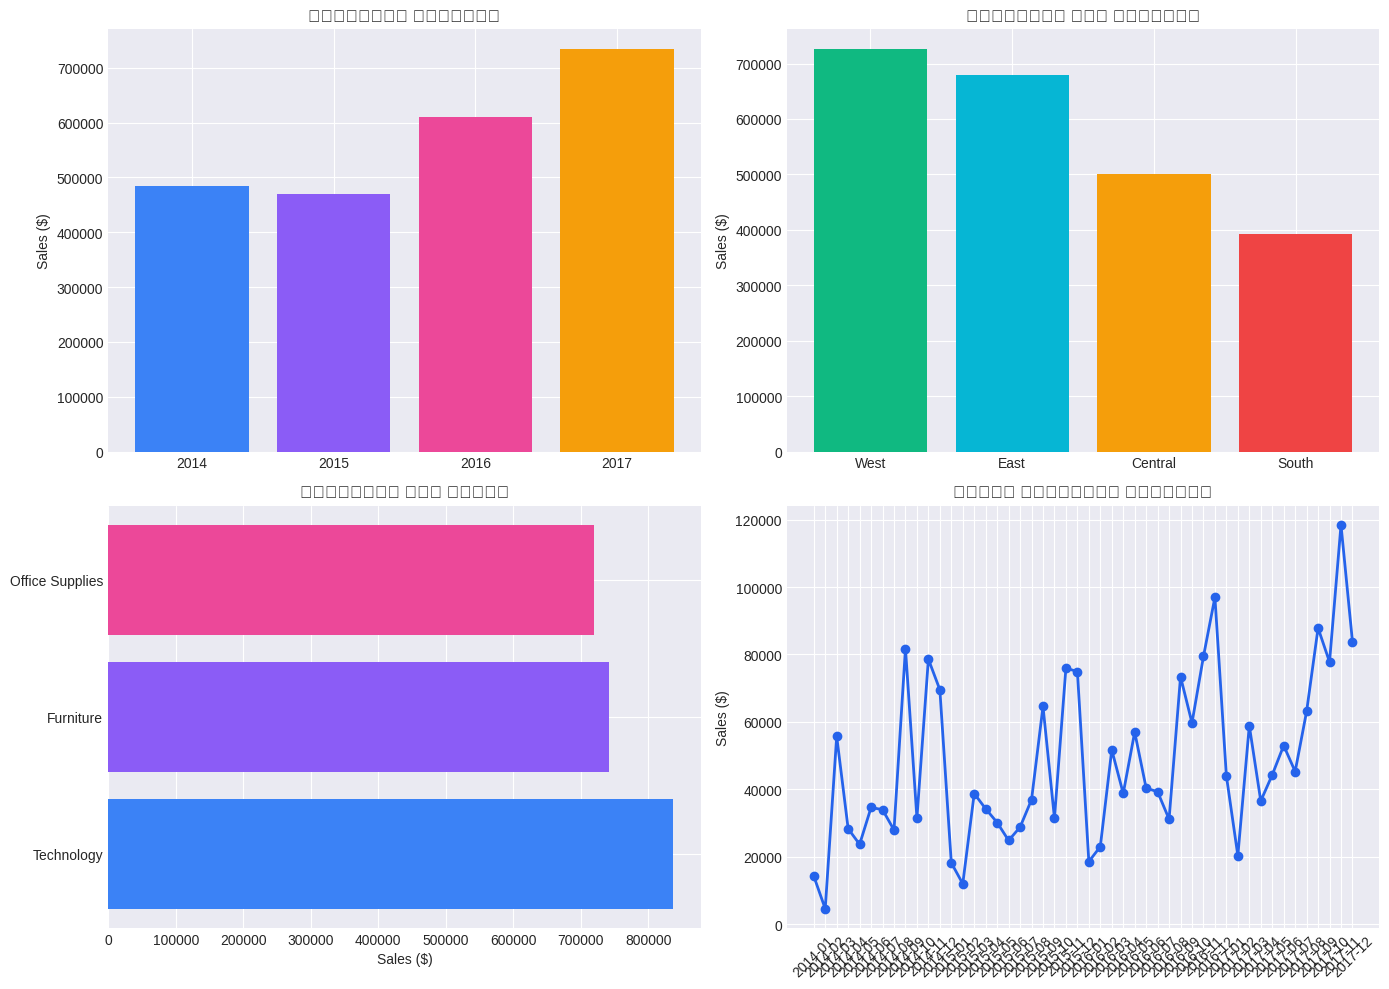

✅ تم إنشاء الرسوم البيانية


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# إعدادات عامة
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 📊 الرسم 1: المبيعات السنوية
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. المبيعات السنوية
axes[0, 0].bar(yearly_sales['Year'].astype(str), yearly_sales['Sales'], color=['#3b82f6', '#8b5cf6', '#ec4899', '#f59e0b'])
axes[0, 0].set_title('المبيعات السنوية', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Sales ($)')

# 2. المبيعات حسب المنطقة
axes[0, 1].bar(region_sales['Region'], region_sales['Sales'], color=['#10b981', '#06b6d4', '#f59e0b', '#ef4444'])
axes[0, 1].set_title('المبيعات حسب المنطقة', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Sales ($)')

# 3. المبيعات حسب الفئة
axes[1, 0].barh(category_sales['Category'], category_sales['Sales'], color=['#3b82f6', '#8b5cf6', '#ec4899'])
axes[1, 0].set_title('المبيعات حسب الفئة', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sales ($)')

# 4. اتجاه المبيعات الشهرية
axes[1, 1].plot(monthly['YearMonth'], monthly['Sales'], marker='o', color='#2563eb', linewidth=2)
axes[1, 1].set_title('اتجاه المبيعات الشهرية', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ تم إنشاء الرسوم البيانية")

In [38]:
# حفظ الملف النظيف
df.to_csv('superstore_cleaned.csv', index=False)
print("✅ تم حفظ الملف: superstore_cleaned.csv")
print("شكل البيانات:", df.shape)

# تحميل الملفات على جهازك
from google.colab import files
files.download('superstore_cleaned.csv')
files.download('sales_analysis.png')

✅ تم حفظ الملف: superstore_cleaned.csv
شكل البيانات: (9994, 23)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>